In [4]:
# CA 76 OHare 

import os
import io
import zipfile
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import urllib.parse
import math
import time
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")

In [5]:
CA_PATH = "Community_Areas.zip"

ca = gpd.read_file(f"zip://{CA_PATH}")

# Project to  WGS84 
ca = ca.to_crs(4326)

print("Columns:", ca.columns.tolist())
print("Rows:", len(ca))
print(" Zip read successfully")

# Common name field is 'community' or 'communityA' depending on vintage; id is 'area_numbe'/'area_num_1'
if 'area_num_1' in ca.columns:
    ca['area_num'] = ca['area_num_1'].astype(int)
elif 'area_numbe' in ca.columns:
    ca['area_num'] = ca['area_numbe'].astype(int)
else:
    raise ValueError("Couldn't find area number field in CA shapefile")

ohare = ca.loc[ca['area_num'] == 76].copy()
assert len(ohare) == 1, "O'Hare (CA 76) not found or duplicated"




Columns: ['area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry']
Rows: 77
 Zip read successfully


In [6]:
import requests, zipfile, io, geopandas as gpd, tempfile, os

def read_zipped_shapefile(url: str) -> gpd.GeoDataFrame:
    """
    Download a ZIP shapefile from a URL, save it temporarily,
    and load it as a GeoDataFrame.
    """
    print(f"  Downloading shapefile from {url} ...")
    r = requests.get(url)
    r.raise_for_status()

    # Create a temporary directory to store the zip
    with tempfile.TemporaryDirectory() as tmpdir:
        zip_path = os.path.join(tmpdir, "temp.zip")
        with open(zip_path, "wb") as f:
            f.write(r.content)

        # Read directly from the saved zip
        gdf = gpd.read_file(f"zip://{zip_path}")
        print(f" Loaded shapefile with {len(gdf)} rows and {len(gdf.columns)} columns.")
        return gdf



In [7]:
# 1) Get Cook County block groups TIGER/Line and intersect with O'Hare
TIGER_BG_URL = "https://www2.census.gov/geo/tiger/TIGER2021/BG/tl_2021_17_bg.zip"

bg_il = read_zipped_shapefile(TIGER_BG_URL).to_crs(4326)
bg_il['COUNTYFP'] = bg_il['COUNTYFP'].astype(str)
bg_cook = bg_il[bg_il['COUNTYFP'] == '031'].copy()

bg_chi = bg_il[bg_il['COUNTYFP'].isin(['031', '043'])].copy()
bg_ohare = gpd.overlay(bg_chi, ohare[['geometry']], how='intersection')
bg_ids = bg_ohare['GEOID'].unique().tolist()
print(f"O'Hare BG count: {len(bg_ids)}")

 Loaded shapefile with 9898 rows and 13 columns.
O'Hare BG count: 33


In [8]:
def fetch_acs_ohare(year: int, variables: list[str], bg_ids: list[str]) -> pd.DataFrame:
    base_url = f"https://api.census.gov/data/{year}/acs/acs5"
    all_data = []

    for geoid in bg_ids:
        state = geoid[:2]
        county = geoid[2:5]
        tract = geoid[5:11]
        bg = geoid[11:]
        var_clause = ",".join(variables)
        params = {
            "get": var_clause + ",state,county,tract,block group",
            "for": f"block group:{bg}",
            "in": f"state:{state} county:{county} tract:{tract}",
            "key": CENSUS_API_KEY,
        }
        r = requests.get(base_url, params=params)
        if r.status_code == 204 or not r.text.strip():
            print(f" {geoid} returned 204 or empty — skipping")
            continue
        if r.status_code != 200:
            print(f" {geoid} returned {r.status_code}: {r.text[:100]}")
            continue
        try:
            rows = r.json()
        except Exception:
            print(f" {geoid} could not decode JSON — skipping")
            continue
        df = pd.DataFrame(rows[1:], columns=rows[0])
        for v in variables:
            df[v] = pd.to_numeric(df[v], errors="coerce")
        df["GEOID"] = geoid
        all_data.append(df)
        time.sleep(0.3)  # respect API rate limits

    if not all_data:
        raise ValueError("No data retrieved for any block groups.")
    df_all = pd.concat(all_data, ignore_index=True)
    print(f" Retrieved {len(df_all)} block groups for {year}")
    return df_all


In [9]:
print(bg_ids[:5])
170314905001
170314902003

['170318105011', '170318105013', '170317608021', '170317608034', '170311705004']


170314902003

In [10]:
ACS_YEARS = [2013, 2014,2015,2016,2017,2018, 2019, 2020, 2021, 2022, 2023]
ACS_VARS = {
    'total_pop': 'B01003_001E',
    'median_age': 'B01002_001E',
    'race_total': 'B02001_001E',
    'race_black': 'B02001_003E',
    'hisp_total': 'B03003_001E',
    'hisp': 'B03003_003E',
    'med_hh_income': 'B19013_001E',
    'pov_universe': 'B17001_001E',
    'pov_below': 'B17001_002E',
    'lf_civilian': 'B23025_003E',
    'unemployed': 'B23025_005E',
    'occ_units': 'B25003_001E',
    'owner_occ': 'B25003_002E',
    'renter_occ': 'B25003_003E',
    'units_total': 'B25002_001E',
    'units_vacant': 'B25002_003E',
}

def fetch_acs_ohare(year: int, variables: list[str], bg_ids: list[str]) -> pd.DataFrame:
    """
    Descarga datos ACS 5-year para una lista de GEOIDs de block groups.
    """
    base_url = f"https://api.census.gov/data/{year}/acs/acs5"
    all_data = []

    for geoid in bg_ids:
        state = geoid[:2]
        county = geoid[2:5]
        tract = geoid[5:11]
        bg = geoid[11:]

        var_clause = ",".join(["NAME"] + variables)

        params = {
            "get": var_clause,
            "for": f"block group:{bg or '*'}",
            "in": f"state:{state} county:{county} tract:{tract}",
            "key": CENSUS_API_KEY,
        }

        try:
            r = requests.get(base_url, params=params)
        except Exception as e:
            print(f" Error de conexión en {geoid}: {e}")
            continue

        if r.status_code != 200:
            print(f" {geoid} → Error {r.status_code}: {r.text[:120]}")
            continue

        try:
            data = r.json()
        except Exception:
            print(f" {geoid} → respuesta no JSON válida")
            continue

        if len(data) < 2:
            print(f" {geoid} → respuesta vacía")
            continue

        df = pd.DataFrame(data[1:], columns=data[0])
        df["GEOID"] = geoid

       
        for v in variables:
            df[v] = pd.to_numeric(df[v], errors="coerce")

        all_data.append(df)
        time.sleep(0.3) 

    if not all_data:
        raise ValueError(f"No se recuperaron datos para ningún block group en {year}")

    df_all = pd.concat(all_data, ignore_index=True)
    print(f" {len(df_all)} filas recuperadas para {year}")
    return df_all


In [11]:
variables = list(ACS_VARS.values())
dfs = []

for year in ACS_YEARS:
    print(f"\n Downloading data from {year}...")
    df_year = fetch_acs_ohare(year, variables, bg_ids)
    df_year["year"] = year  
    dfs.append(df_year)


df_all_years = pd.concat(dfs, ignore_index=True)

print(" Combined data for all years:", df_all_years.shape)
print(df_all_years.head())

out_dir = "OHare-CA76"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "acs_blockgroups_all_years2013-2023.csv")
df_all_years.to_csv(out_path, index=False)
print("CSV saved in:", out_path)



 33 filas recuperadas para 2013

 33 filas recuperadas para 2014

 33 filas recuperadas para 2015

 33 filas recuperadas para 2016

 33 filas recuperadas para 2017

 33 filas recuperadas para 2018

 33 filas recuperadas para 2019

 33 filas recuperadas para 2020

 33 filas recuperadas para 2021

 33 filas recuperadas para 2022

 33 filas recuperadas para 2023
 Combined data for all years: (363, 23)
                                                NAME  B01003_001E  \
0  Block Group 1, Census Tract 8105.01, Cook Coun...          842   
1  Block Group 3, Census Tract 8105.01, Cook Coun...          830   
2  Block Group 1, Census Tract 7608.02, Cook Coun...         2191   
3  Block Group 4, Census Tract 7608.03, Cook Coun...         1587   
4  Block Group 4, Census Tract 1705, Cook County,...         1015   

   B01002_001E  B02001_001E  B02001_003E  B03003_001E  B03003_003E  \
0         50.6          842            0          842           36   
1         59.3          830            0  

# PLOTS

In [12]:
import pandas as pd

df = pd.read_csv("OHare-CA76/acs_blockgroups_all_years2013-2023.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(363, 23)
['NAME', 'B01003_001E', 'B01002_001E', 'B02001_001E', 'B02001_003E', 'B03003_001E', 'B03003_003E', 'B19013_001E', 'B17001_001E', 'B17001_002E', 'B23025_003E', 'B23025_005E', 'B25003_001E', 'B25003_002E', 'B25003_003E', 'B25002_001E', 'B25002_003E', 'state', 'county', 'tract', 'block group', 'GEOID', 'year']


,NAME,B01003_001E,B01002_001E,B02001_001E,B02001_003E,B03003_001E,B03003_003E,B19013_001E,B17001_001E,B17001_002E,...,B25003_002E,B25003_003E,B25002_001E,B25002_003E,state,county,tract,block group,GEOID,year
0,"Block Group 1, Census Tract 8105.01, Cook Coun...",842,50.6,842,0,842,36,42102,NaN,NaN,...,385,20,420,15,17,31,810501,1,170318105011,2013
1,"Block Group 3, Census Tract 8105.01, Cook Coun...",830,59.3,830,0,830,29,50139,NaN,NaN,...,333,0,343,10,17,31,810501,3,170318105013,2013
2,"Block Group 1, Census Tract 7608.02, Cook Coun...",2191,50.1,2191,0,2191,244,42159,NaN,NaN,...,845,240,1189,104,17,31,760802,1,170317608021,2013
3,"Block Group 4, Census Tract 7608.03, Cook Coun...",1587,37.6,1587,1,1587,554,50977,NaN,NaN,...,281,312,628,35,17,31,760803,4,170317608034,2013
4,"Block Group 4, Census Tract 1705, Cook County,...",1015,38.2,1015,17,1015,217,52292,NaN,NaN,...,290,116,441,35,17,31,170500,4,170311705004,2013


Data cleaning

In [13]:
import numpy as np

# Relevant numeric columns
cols = [
    "B01003_001E",  # total population
    "B19013_001E",  # median income
    "B01002_001E",  # median age
    "B23025_005E",  # unemployed
    "B23025_003E",  # labor force
    "B25003_002E",  # owner occupied
    "B25003_001E",  # total occupied
    "B25002_003E",  # vacant units
    "B25002_001E",  # total units
]

# Replace zeros or negative values for NaN
for c in cols:
    df.loc[df[c] <= 0, c] = np.nan
    

for c in ["B19013_001E", "B01003_001E"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 3*iqr, q3 + 3*iqr
    df.loc[(df[c] < lower) | (df[c] > upper), c] = np.nan

In [14]:
[x for x in df.columns if 'B02001' in x or 'B03003' in x]
df['pct_black'] = df['B02001_003E'] / df['B02001_001E']


In [15]:
def weighted_avg(values, weights):
    mask = (~values.isna()) & (~weights.isna())
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

ca_ts = (
    df.groupby("year")
    .apply(lambda g: pd.Series({
        "total_pop": g["B01003_001E"].sum(),
        "median_income": weighted_avg(g["B19013_001E"], g["B01003_001E"]),
        "median_age": weighted_avg(g["B01002_001E"], g["B01003_001E"]),
        "pct_black": weighted_avg(g["pct_black"], g["B01003_001E"]),
        "unemployed": g["B23025_005E"].sum(),
        "labor_force": g["B23025_003E"].sum(),
        "owner_occupied": g["B25003_002E"].sum(),
        "total_occupied": g["B25003_001E"].sum(),
        "vacant_units": g["B25002_003E"].sum(),
        "total_units": g["B25002_001E"].sum(),
    }))
    .reset_index()
)

ca_ts["unemp_rate"] = ca_ts["unemployed"] / ca_ts["labor_force"]
ca_ts["owner_share"] = ca_ts["owner_occupied"] / ca_ts["total_occupied"]
ca_ts["vacancy_rate"] = ca_ts["vacant_units"] / ca_ts["total_units"]


ca_ts.head()


C:\Users\Judit Martín\AppData\Local\Temp\ipykernel_24672\1392738524.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,year,total_pop,median_income,median_age,pct_black,unemployed,labor_force,owner_occupied,total_occupied,vacant_units,total_units,unemp_rate,owner_share,vacancy_rate
0,2013,51278.0,49371.062600,39.601459,0.016986,2295.0,27863.0,12287.0,20418.0,1569.0,21987.0,0.082367,0.601773,0.071360
1,2014,52058.0,52327.074263,39.261074,0.013274,2339.0,27958.0,12389.0,20213.0,1673.0,21886.0,0.083661,0.612922,0.076442
2,2015,52503.0,57879.506942,39.732989,0.014399,2229.0,28331.0,12346.0,20202.0,1614.0,21816.0,0.078677,0.611128,0.073982
3,2016,52273.0,61958.071085,39.725382,0.014348,2059.0,28717.0,12213.0,20107.0,1532.0,21639.0,0.071700,0.607400,0.070798
4,2017,51172.0,64468.273143,40.229373,0.011764,1735.0,27604.0,11809.0,19904.0,1452.0,21356.0,0.062853,0.593298,0.067990


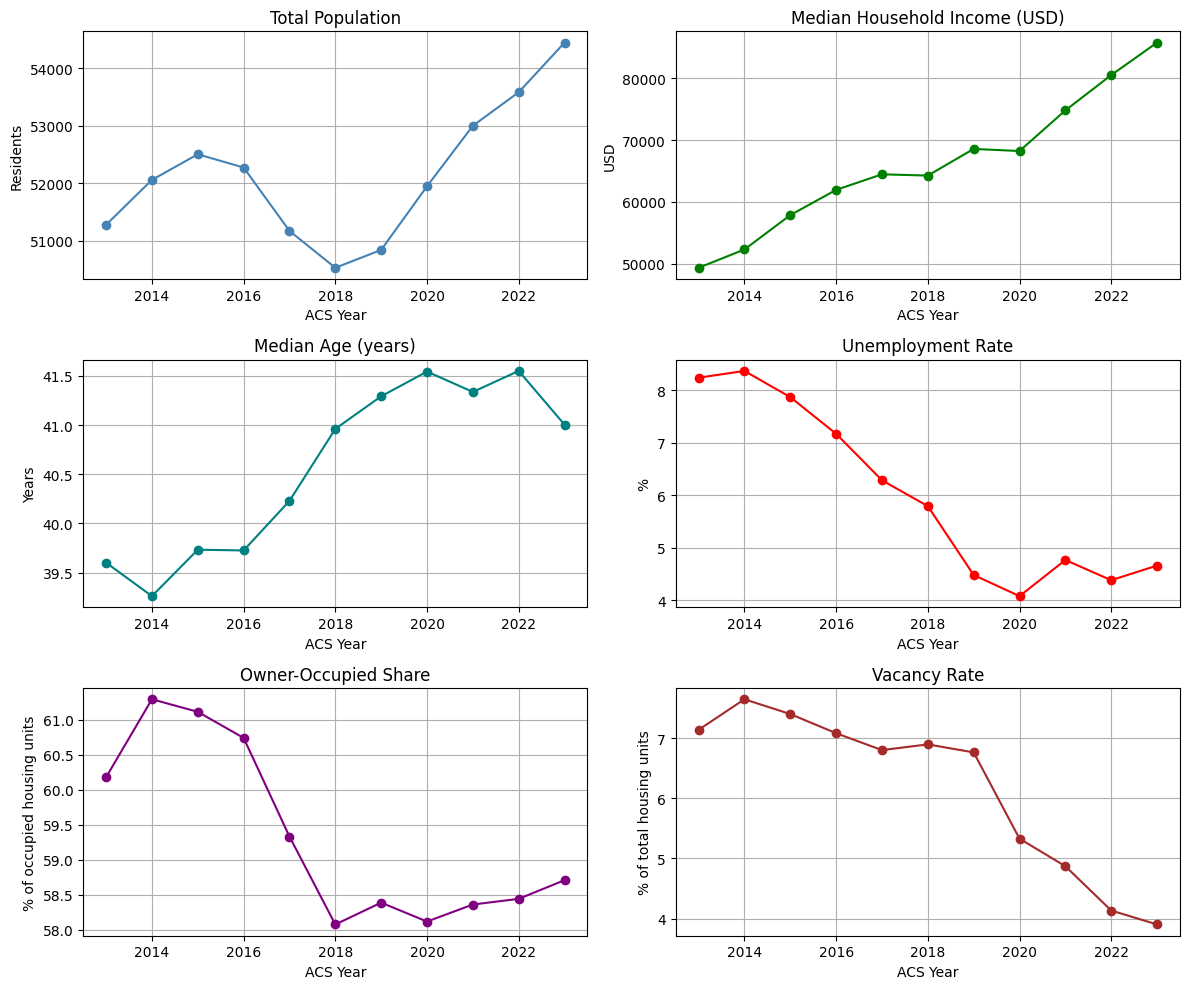

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12,10))
axes = axes.flatten()

# 1. Population
axes[0].plot(ca_ts['year'], ca_ts['total_pop'], marker='o', color='steelblue')
axes[0].set_title('Total Population')
axes[0].set_ylabel('Residents')

# 2. Median household income
axes[1].plot(ca_ts['year'], ca_ts['median_income'], marker='o', color='green')
axes[1].set_title('Median Household Income (USD)')
axes[1].set_ylabel('USD')

# 3. Median age
axes[2].plot(ca_ts['year'], ca_ts['median_age'], marker='o', color='teal')
axes[2].set_title('Median Age (years)')
axes[2].set_ylabel('Years')

# 4. Unemployment rate
axes[3].plot(ca_ts['year'], ca_ts['unemp_rate']*100, marker='o', color='red')
axes[3].set_title('Unemployment Rate')
axes[3].set_ylabel('%')

# 5. Owner-occupied share
axes[4].plot(ca_ts['year'], ca_ts['owner_share']*100, marker='o', color='purple')
axes[4].set_title('Owner-Occupied Share')
axes[4].set_ylabel('% of occupied housing units')

# 6. Vacancy rate
axes[5].plot(ca_ts['year'], ca_ts['vacancy_rate']*100, marker='o', color='brown')
axes[5].set_title('Vacancy Rate')
axes[5].set_ylabel('% of total housing units')

for ax in axes:
    ax.set_xlabel('ACS Year')
    ax.grid(True)

plt.tight_layout()
plt.show()

out_dir = "OHare-CA76"   
os.makedirs(out_dir, exist_ok=True)
fig.savefig("OHare-CA76/ohare_trends.png", dpi=300, bbox_inches='tight')



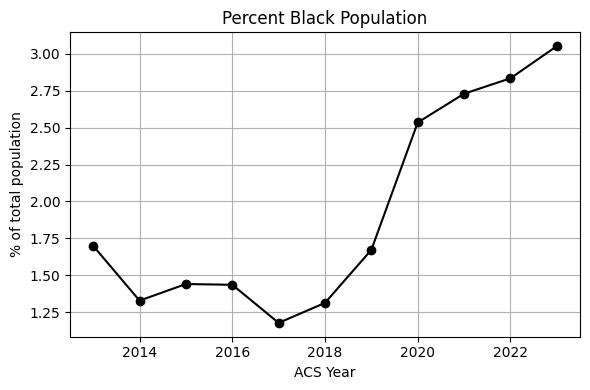

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ca_ts['year'], ca_ts['pct_black']*100, marker='o', color='black')
ax.set_title('Percent Black Population')
ax.set_xlabel('ACS Year')
ax.set_ylabel('% of total population')
ax.grid(True)
plt.tight_layout()
plt.show()


## Economic analaysis


In [18]:
ca_ts = ca_ts[ca_ts['labor_force'] > 0]
ca_ts[['year','total_pop','labor_force','unemployed']].diff().describe()


,year,total_pop,labor_force,unemployed
count,10.0,10.000000,10.000000,10.000000
mean,1.0,316.500000,228.800000,-88.900000
std,0.0,744.379122,602.256461,177.902876
min,1.0,-1101.000000,-1113.000000,-340.000000
25%,1.0,-94.750000,-63.250000,-164.250000
50%,1.0,513.500000,379.500000,-97.500000
75%,1.0,841.500000,600.750000,13.250000
max,1.0,1105.000000,967.000000,243.000000


In [19]:
# Estimates come from ACS 5-Year Data at the block group level.
# Due to the small sample size, year-to-year variations in the series
# do not necessarily reflect real demographic changes.
ca_ts[['total_pop', 'labor_force', 'unemployed', 'median_income']] = (
    ca_ts[['total_pop', 'labor_force', 'unemployed', 'median_income']].rolling(3, center=True, min_periods=1).mean()
)


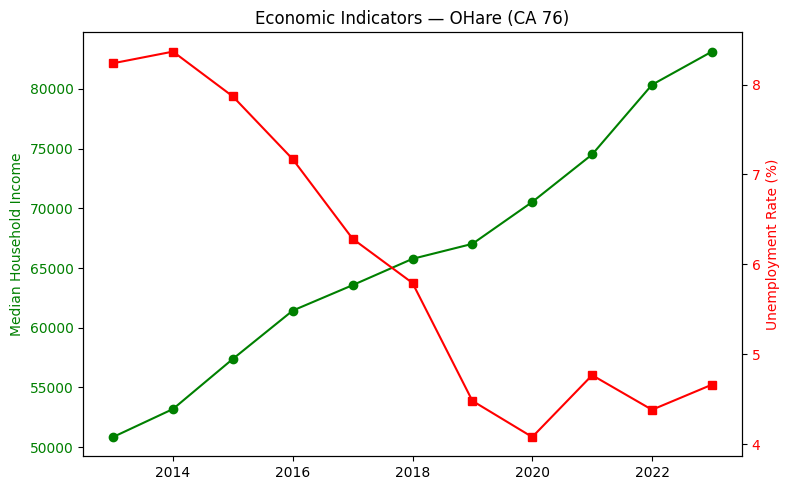

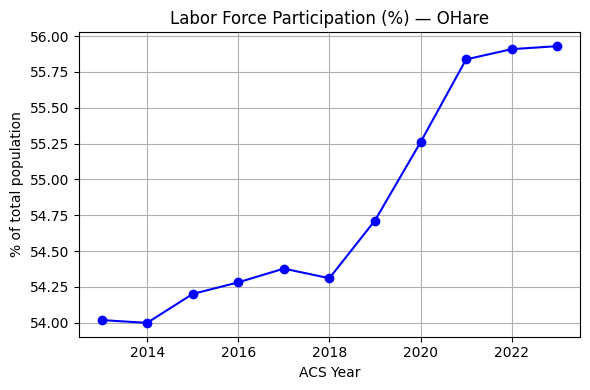

In [20]:
import matplotlib.pyplot as plt

# Calculate workforce participation (optional)
ca_ts['labor_force_participation'] = ca_ts['labor_force'] / ca_ts['total_pop']


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(ca_ts['year'], ca_ts['median_income'], marker='o', color='green', label='Median Household Income (USD)')
ax.set_ylabel('Median Household Income', color='green')
ax.tick_params(axis='y', labelcolor='green')

# Twin axis for unemployment rate
ax2 = ax.twinx()
ax2.plot(ca_ts['year'], ca_ts['unemp_rate']*100, marker='s', color='red', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Economic Indicators — OHare (CA 76)')
plt.tight_layout()
plt.show()

# Plot labor force participation
plt.figure(figsize=(6,4))
plt.plot(ca_ts['year'], ca_ts['labor_force_participation']*100, marker='o', color='blue')
plt.title('Labor Force Participation (%) — OHare')
plt.xlabel('ACS Year')
plt.ylabel('% of total population')
plt.grid(True)
plt.tight_layout()
plt.show()


## Temporal change analysis

In [21]:
ca_ts[['year', 'median_income']].head(10)

,year,median_income
0,2013,50849.068432
1,2014,53192.547935
2,2015,57388.217430
3,2016,61435.283724
4,2017,63564.781164
5,2018,65768.211349
6,2019,67022.675232
7,2020,70531.634489
8,2021,74508.871609
9,2022,80346.097176


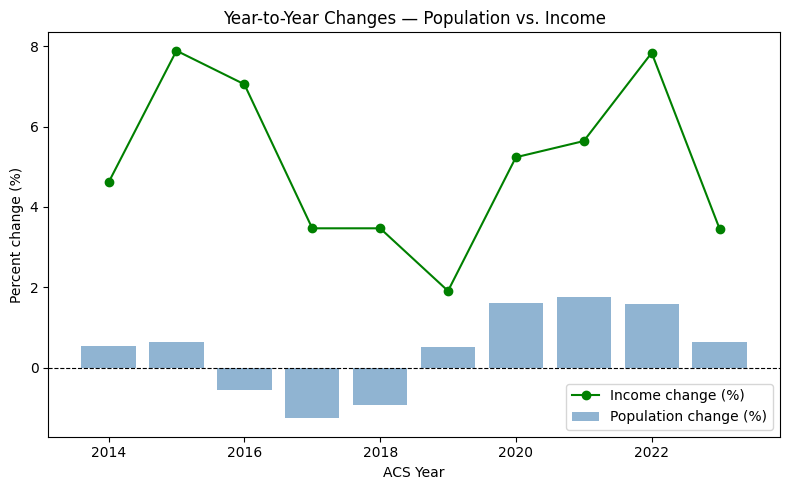

,year,total_pop_change_pct,median_income_change_pct,owner_share_change_pct,vacancy_rate_change_pct,unemp_rate_change_pct
0,2013,NaN,NaN,NaN,NaN,NaN
1,2014,0.54,4.61,1.85,7.12,1.57
2,2015,0.64,7.89,-0.29,-3.22,-5.96
3,2016,-0.56,7.05,-0.61,-4.30,-8.87
4,2017,-1.26,3.47,-2.32,-3.97,-12.34
5,2018,-0.93,3.47,-2.12,1.40,-7.82
6,2019,0.51,1.91,0.54,-1.93,-22.62
7,2020,1.61,5.24,-0.46,-21.21,-8.96
8,2021,1.76,5.64,0.42,-8.59,16.84
9,2022,1.57,7.83,0.14,-15.12,-8.06


In [22]:
import numpy as np

# Compute year-to-year percent changes
for col in ['total_pop', 'median_income', 'owner_share', 'vacancy_rate', 'unemp_rate']:
    ca_ts[f'{col}_change_pct'] = ca_ts[col].pct_change() * 100

# Plot population and income change
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(ca_ts['year'], ca_ts['total_pop_change_pct'], color='steelblue', alpha=0.6, label='Population change (%)')
ax.plot(ca_ts['year'], ca_ts['median_income_change_pct'], color='green', marker='o', label='Income change (%)')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Year-to-Year Changes — Population vs. Income')
ax.set_xlabel('ACS Year')
ax.set_ylabel('Percent change (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Overall summary of percent changes
ca_ts[['year'] + [c for c in ca_ts.columns if c.endswith('_change_pct')]].round(2)


## Well being index

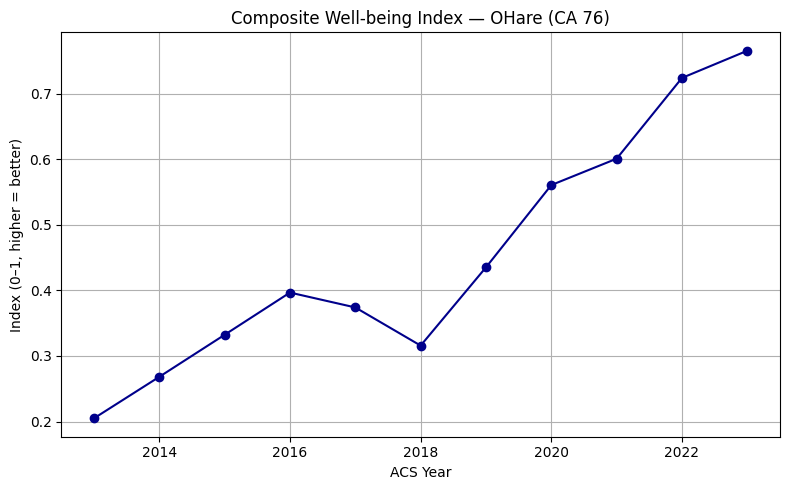

,year,wellbeing_index
0,2013,0.205
1,2014,0.268
2,2015,0.332
3,2016,0.397
4,2017,0.374
5,2018,0.316
6,2019,0.435
7,2020,0.560
8,2021,0.601
9,2022,0.724


In [23]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Select variables to include in the composite index
cols = ['median_income', 'owner_share', 'unemp_rate', 'vacancy_rate']
scaler = MinMaxScaler()

# Normalize: higher = better conditions
ca_norm = ca_ts.copy()
ca_norm[cols] = scaler.fit_transform(ca_ts[cols])

# Invert negative indicators so higher = better
ca_norm['unemp_rate'] = 1 - ca_norm['unemp_rate']
ca_norm['vacancy_rate'] = 1 - ca_norm['vacancy_rate']

# Compute the composite
ca_ts['wellbeing_index'] = (
    ca_norm['median_income'] + ca_norm['owner_share'] + 
    ca_norm['unemp_rate'] + ca_norm['vacancy_rate']
) / 4

# Plot the index
plt.figure(figsize=(8,5))
plt.plot(ca_ts['year'], ca_ts['wellbeing_index'], marker='o', color='darkblue')
plt.title('Composite Well-being Index — OHare (CA 76)')
plt.xlabel('ACS Year')
plt.ylabel('Index (0–1, higher = better)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: inspect data
ca_ts[['year', 'wellbeing_index']].round(3)


## Comparation between 2010 and 2020

   Year  Total Population  Hispanic (%)  NH White (%)  NH Black (%)  \
0  2010             25987      1.073614      0.515642     97.087005   
1  2020             21524      2.666791      0.780524     94.053150   

   NH Asian (%)  NH Other (%)  
0      0.026937      1.296802  
1      0.130087      2.369448  
Sum (%) each year: [100.0, 100.0]


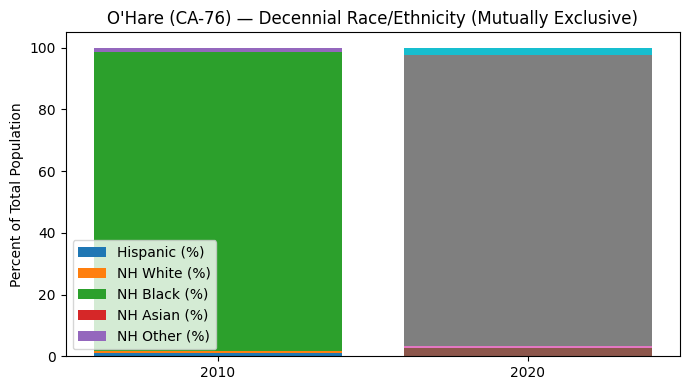

O'Hare Total Population 2010: 25,987
O'Hare Total Population 2020: 21,524
Change: -4,463 people (-17.17%)
Saved decennial files in OHare-CA76/


In [24]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
CENSUS_API_KEY = CENSUS_API_KEY  # assumes it is already defined in your environment/session

# O'Hare tract GEOIDs (Cook County, IL)
ohare_tracts = [
    "17031490100","17031490200","17031490300","17031490400",
    "17031490500","17031490600","17031490700","17031490800",
    "17031490900","17031491000","17031491100","17031491200",
    "17031491300"
]
STATE = "17"   # Illinois
COUNTY = "031" # Cook

# =========================
# Helper: fetch decennial
# =========================
import requests
import pandas as pd

def fetch_decennial(year, dataset, variables, state, county, tracts, api_key=None):
    """
    Hace UNA petición: for=tract:* en state+county, luego filtra por tus tractos.
    Maneja errores de la API y convierte a numérico.
    """
    url = f"https://api.census.gov/data/{year}/dec/{dataset}"
    params = {
        "get": ",".join(["NAME"] + list(variables.values())),
        "for": "tract:*",
        "in": f"state:{state} county:{county}",
    }
    if api_key:
        params["key"] = api_key

    r = requests.get(url, params=params)
    try:
        r.raise_for_status()
        data = r.json()
    except Exception:
        # Debug útil: ver exactamente qué respondió la API
        snippet = (r.text or "")[:500]
        raise RuntimeError(
            f"Census API error ({r.status_code}). URL:\n{r.url}\n\nResponse (first 500 chars):\n{snippet}"
        )

    df = pd.DataFrame(data[1:], columns=data[0])

    # Construye GEOID11 para filtrar tus tractos
    # La API devuelve 'state','county','tract' por separado
    for c in ["state", "county", "tract"]:
        if c not in df.columns:
            raise KeyError(f"Missing '{c}' in Census response columns: {df.columns.tolist()}")

    df["state"] = df["state"].astype(str).str.zfill(2)
    df["county"] = df["county"].astype(str).str.zfill(3)
    df["tract"] = df["tract"].astype(str).str.zfill(6)
    df["GEOID"] = df["state"] + df["county"] + df["tract"]

    # Filtra solo tus tractos
    wanted = set(tracts)
    df = df[df["GEOID"].isin(wanted)].copy()

    # Renombra códigos -> nombres amigables y convierte a numérico
    code2name = {v: k for k, v in variables.items()}
    df.rename(columns=code2name, inplace=True)
    for k in variables.keys():
        df[k] = pd.to_numeric(df[k], errors="coerce")

    return df

vars_2010 = {
    "pop_2010":      "P001001",  # total
    "nh_total_2010": "P005002",  # NOT Hispanic or Latino (total)
    "nh_white_2010": "P005003",  # Not Hispanic: White alone
    "nh_black_2010": "P005004",  # Not Hispanic: Black alone
    "nh_asian_2010": "P005007",  # Not Hispanic: Asian alone
    # (we will compute hisp_2010 = pop_2010 - nh_total_2010)
}


# 2020 PL: P2
vars_2020 = {
    "pop_2020":      "P1_001N",  # Total population
    "hisp_2020":     "P2_002N",  # Hispanic or Latino
    "nh_total_2020": "P2_003N",  # Not Hispanic or Latino (total)
    "nh_white_2020": "P2_005N",  # Not Hispanic: White alone
    "nh_black_2020": "P2_006N",  # Not Hispanic: Black alone
    "nh_asian_2020": "P2_008N",  # Not Hispanic: Asian alone
    # (extra opcional: AIAN=P2_007N, NHPI=P2_009N, Other=P2_010N, Two+=P2_011N)
}

df2010 = fetch_decennial(2010, "sf1", vars_2010, STATE, COUNTY, ohare_tracts, api_key=CENSUS_API_KEY if 'CENSUS_API_KEY' in globals() else None)
df2020 = fetch_decennial(2020, "pl",  vars_2020, STATE, COUNTY, ohare_tracts, api_key=CENSUS_API_KEY if 'CENSUS_API_KEY' in globals() else None)


# =========================
# Merge by tract
# =========================
df = pd.merge(
    df2010[["tract"] + list(vars_2010.keys())],
    df2020[["tract"] + list(vars_2020.keys())],
    on="tract",
    how="inner"
)

# Reconstruct Hispanic 2010 safely
df["hisp_2010"] = df["pop_2010"] - df["nh_total_2010"]
df["hisp_2010"] = df["hisp_2010"].clip(lower=0)  # guard against tiny negatives

# =========================
# Changes (population)
# =========================
df["pop_change"] = df["pop_2020"] - df["pop_2010"]
df["pct_change"] = (df["pop_change"] / df["pop_2010"]) * 100

# =========================
# Composition (% of total pop, mutually exclusive)
# =========================
for grp in ["hisp", "nh_white", "nh_black", "nh_asian"]:
    for y in [2010, 2020]:
        num = f"{grp}_{y}"
        den = f"pop_{y}"
        df[f"{grp}_pct_{y}"] = (df[num] / df[den]) * 100

# Sum counts across O'Hare tracts
pop10 = df["pop_2010"].sum(); pop20 = df["pop_2020"].sum()
hisp10 = df["hisp_2010"].sum(); hisp20 = df["hisp_2020"].sum()
nhw10 = df["nh_white_2010"].sum(); nhw20 = df["nh_white_2020"].sum()
nhb10 = df["nh_black_2010"].sum(); nhb20 = df["nh_black_2020"].sum()
nha10 = df["nh_asian_2010"].sum(); nha20 = df["nh_asian_2020"].sum()
nht10 = df["nh_total_2010"].sum(); nht20 = df["nh_total_2020"].sum()

# Residual Not-Hispanic “Other” = NH total − (NH White + NH Black + NH Asian)
nh_other10 = max(nht10 - (nhw10 + nhb10 + nha10), 0)
nh_other20 = max(nht20 - (nhw20 + nhb20 + nha20), 0)

# =========================
# Aggregate across all O'Hare tracts (area-level totals)
# =========================
agg_data = pd.DataFrame({
    "Year": [2010, 2020],
    "Total Population": [pop10, pop20],
    "Hispanic (%)": [hisp10/pop10*100, hisp20/pop20*100],
    "NH White (%)": [nhw10/pop10*100, nhw20/pop20*100],
    "NH Black (%)": [nhb10/pop10*100, nhb20/pop20*100],
    "NH Asian (%)": [nha10/pop10*100, nha20/pop20*100],
    "NH Other (%)": [nh_other10/pop10*100, nh_other20/pop20*100],
})
print(agg_data)
print("Sum (%) each year:",
      (agg_data[["Hispanic (%)","NH White (%)","NH Black (%)","NH Asian (%)","NH Other (%)"]]
       .sum(axis=1).round(2)).tolist())


# =========================
# Plot (stacked bars of composition)
# =========================
# reshape for plotting
groups = ["Hispanic (%)","NH White (%)","NH Black (%)","NH Asian (%)","NH Other (%)"]

plot_df = agg_data.melt(id_vars=["Year","Total Population"],
                        value_vars=groups, var_name="Group", value_name="Percent")

import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
for i, y in enumerate(agg_data["Year"]):
    subset = plot_df[plot_df["Year"] == y]
    bottom = 0.0
    for grp in groups:
        val = float(subset.loc[subset["Group"] == grp, "Percent"].iloc[0])  # iloc para evitar FutureWarning
        plt.bar(str(y), val, bottom=bottom, label=grp if i == 0 else None)
        bottom += val

plt.title("O'Hare (CA-76) — Decennial Race/Ethnicity (Mutually Exclusive)")
plt.ylabel("Percent of Total Population")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# Population change summary
# =========================
p2010 = int(agg_data.loc[agg_data["Year"] == 2010, "Total Population"].item())
p2020 = int(agg_data.loc[agg_data["Year"] == 2020, "Total Population"].item())
delta = p2020 - p2010
pct = (delta / p2010) * 100 if p2010 > 0 else float("nan")

print(f"O'Hare Total Population 2010: {p2010:,}")
print(f"O'Hare Total Population 2020: {p2020:,}")
print(f"Change: {delta:+,} people ({pct:.2f}%)")

# =========================
# Export
# =========================
df.to_csv("OHare-CA76/OHare_Chicago_Decennial_2010_2020_mutually_exclusive.csv", index=False)
agg_data.to_csv("OHare-CA76/OHare_Chicago_Decennial_agg_2010_2020.csv", index=False)
print("Saved decennial files in OHare-CA76/")


   Year  Total Population  White (%)  Black (%)  Asian (%)  Hispanic (%)
0  2010           25987.0   0.661869  97.537230   0.080810      1.073614
1  2020           21524.0   0.998885  94.652481   0.144025      2.666791


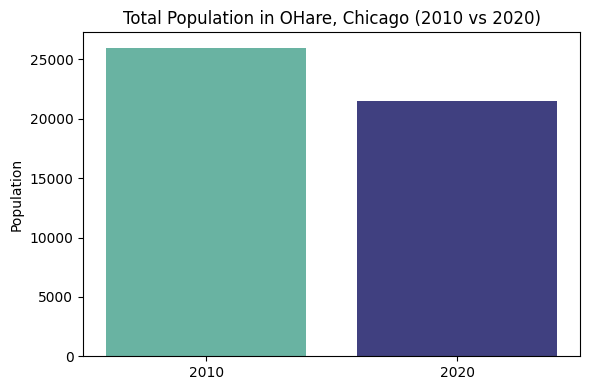

 OHare Total Population 2010: 25,987.0
 OHare Total Population 2020: 21,524.0
 Change: -4,463.0 people (-17.17%)


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# If you already have the tract-level CSV
df = pd.read_csv("OHare-CA76/OHare_Chicago_Decennial_2010_2020.csv")

# Aggregate all OHare tracts into one total
agg = df.sum(numeric_only=True)

# Compute shares
agg_data = pd.DataFrame({
    "Year": [2010, 2020],
    "Total Population": [agg["pop_2010"], agg["pop_2020"]],
    "White (%)": [agg["white_2010"] / agg["pop_2010"] * 100,
                  agg["white_2020"] / agg["pop_2020"] * 100],
    "Black (%)": [agg["black_2010"] / agg["pop_2010"] * 100,
                  agg["black_2020"] / agg["pop_2020"] * 100],
    "Asian (%)": [agg["asian_2010"] / agg["pop_2010"] * 100,
                  agg["asian_2020"] / agg["pop_2020"] * 100],
    "Hispanic (%)": [agg["hisp_2010"] / agg["pop_2010"] * 100,
                     agg["hisp_2020"] / agg["pop_2020"] * 100],
})
print(agg_data)

plt.figure(figsize=(6, 4))
plt.bar(agg_data["Year"].astype(str), agg_data["Total Population"], color=["#69b3a2", "#404080"])
plt.title("Total Population in OHare, Chicago (2010 vs 2020)")
plt.ylabel("Population")
plt.tight_layout()
plt.show()

pop_change = agg["pop_2020"] - agg["pop_2010"]
pct_change = (pop_change / agg["pop_2010"]) * 100

print(f" OHare Total Population 2010: {agg['pop_2010']:,}")
print(f" OHare Total Population 2020: {agg['pop_2020']:,}")
print(f" Change: {pop_change:+,} people ({pct_change:.2f}%)")


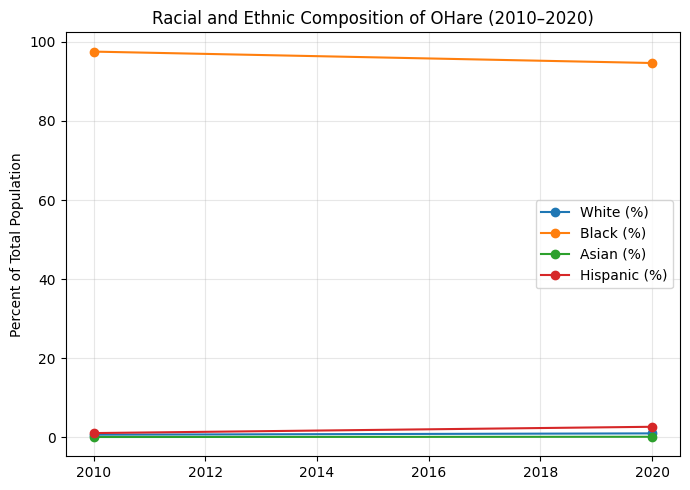

In [26]:
# Melt the data for grouped bar chart
race_data = agg_data.melt(id_vars="Year", value_vars=["White (%)", "Black (%)", "Asian (%)", "Hispanic (%)"])

plt.figure(figsize=(7, 5))
for race in ["White (%)", "Black (%)", "Asian (%)", "Hispanic (%)"]:
    subset = race_data[race_data["variable"] == race]
    plt.plot(subset["Year"], subset["value"], marker="o", label=race)

plt.title("Racial and Ethnic Composition of OHare (2010–2020)")
plt.ylabel("Percent of Total Population")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


years in csv: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Total population 2013 = 51,278
Total population 2023 = 54,443


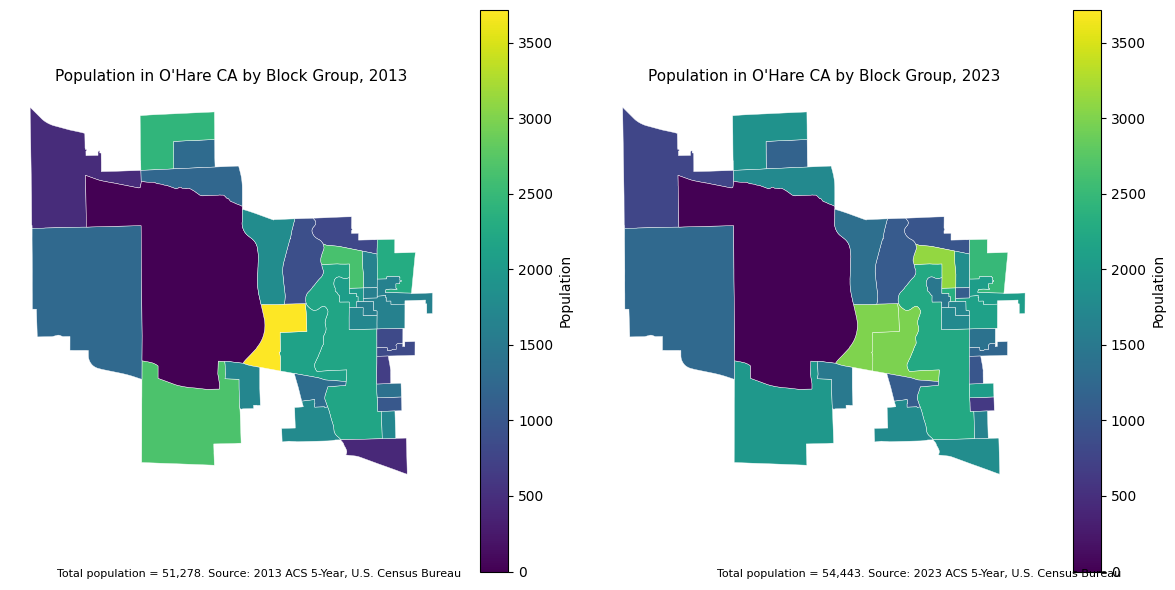

In [27]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 1) Load O'Hare block groups (your 60 BG file)
# -----------------------------------------------------
# Use the filename you saved: e.g., ohare_60bg.geojson / ohare_60bg_v2.geojson
ohare_bg = gpd.read_file("OHare-CA76/ohare_60bg_v2.geojson").to_crs(4326)

# Ensure a consistent GEOID field and 12-digit padding for BGs
geo_col = "GEOID" if "GEOID" in ohare_bg.columns else "GEOIDBG"
ohare_bg[geo_col] = ohare_bg[geo_col].astype(str).str.zfill(12)

# -----------------------------------------------------
# 2) Load ACS panel for those BGs
# -----------------------------------------------------
df = pd.read_csv("OHare-CA76/acs_blockgroups_all_years2013-2023.csv")
df["GEOID"] = df["GEOID"].astype(str).str.zfill(12)

# Keep only the BGs present in your GeoJSON
ohare_geoids = ohare_bg[geo_col].unique().tolist()
df_ohare = df[df["GEOID"].isin(ohare_geoids)].copy()

# -----------------------------------------------------
# 3) Pick start and end years
# -----------------------------------------------------
available_years = sorted(df_ohare["year"].unique())
print("years in csv:", available_years)

year_start = 2013
# Prefer 2023 if available; otherwise fall back to 2022
year_end = 2023 if 2023 in available_years else 2022

# Keep population only and rename for clarity
df_ohare = (
    df_ohare[["GEOID", "year", "B01003_001E"]]
    .rename(columns={"B01003_001E": "population"})
)

# Filter to the two selected years
df_ohare = df_ohare[df_ohare["year"].isin([year_start, year_end])]

# Pivot to wide: one row per BG, columns = population in each year
pop_pivot = (
    df_ohare
    .pivot(index="GEOID", columns="year", values="population")
    .reset_index()
)

# Rename columns to explicit year labels
if year_end == 2023:
    pop_pivot.columns = ["GEOID", "pop_2013", "pop_2023"]
else:
    pop_pivot.columns = ["GEOID", "pop_2013", "pop_2022"]

# Merge population back to geometry
gdf = ohare_bg.merge(pop_pivot, left_on=geo_col, right_on="GEOID", how="left")

# -----------------------------------------------------
# 4) Totals and a shared color scale across both maps
# -----------------------------------------------------
if year_end == 2023:
    pop_2013_total = int(np.nansum(gdf["pop_2013"]))
    pop_202X_total = int(np.nansum(gdf["pop_2023"]))
    vmin = np.nanmin(gdf[["pop_2013", "pop_2023"]].to_numpy())
    vmax = np.nanmax(gdf[["pop_2013", "pop_2023"]].to_numpy())
else:
    pop_2013_total = int(np.nansum(gdf["pop_2013"]))
    pop_202X_total = int(np.nansum(gdf["pop_2022"]))
    vmin = np.nanmin(gdf[["pop_2013", "pop_2022"]].to_numpy())
    vmax = np.nanmax(gdf[["pop_2013", "pop_2022"]].to_numpy())

print(f"Total population {year_start} = {pop_2013_total:,}")
print(f"Total population {year_end} = {pop_202X_total:,}")

# -----------------------------------------------------
# 5) Side-by-side maps
# -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: start year (2013)
gdf.plot(
    column="pop_2013",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Population"},
    ax=axes[0],
    vmin=vmin, vmax=vmax
)
axes[0].set_title(f"Population in O'Hare CA by Block Group, {year_start}", fontsize=11)
axes[0].axis("off")

# Right: end year (2022 or 2023)
right_col = "pop_2023" if year_end == 2023 else "pop_2022"
gdf.plot(
    column=right_col,
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Population"},
    ax=axes[1],
    vmin=vmin, vmax=vmax
)
axes[1].set_title(f"Population in O'Hare CA by Block Group, {year_end}", fontsize=11)
axes[1].axis("off")

plt.tight_layout()

# Captions beneath each panel
fig.text(
    0.22, 0.03,
    f"Total population = {pop_2013_total:,}. Source: {year_start} ACS 5-Year, U.S. Census Bureau",
    ha="center", fontsize=8
)
fig.text(
    0.77, 0.03,
    f"Total population = {pop_202X_total:,}. Source: {year_end} ACS 5-Year, U.S. Census Bureau",
    ha="center", fontsize=8
)

plt.show()


In [28]:
TARGET_CA = 76
target_ca = ca.loc[ca['area_num'] == TARGET_CA].copy()
geom_target = target_ca.geometry.iloc[0]

neighbors = ca[ca.geometry.touches(geom_target)].copy()
print(neighbors[['area_num', 'community']])

    area_num     community
9         10  NORWOOD PARK
16        17       DUNNING


In [29]:
BG_PATH = "tl_2020_17_bg.zip"   
bg = gpd.read_file(f"zip://{BG_PATH}").to_crs(4326)

# assign each block group to a Community Area based on spatial overlap
bg_ca = gpd.sjoin(bg, ca[['area_num', 'geometry']], how='left', predicate='intersects')

In [30]:
bg_counts = bg_ca.groupby('area_num').size().sort_values(ascending=False)
print(bg_counts)
print("BG of OHare (CA 76):", bg_counts.get(76, 0))

area_num
25.0    123
6.0     105
22.0     94
24.0     88
8.0      81
       ... 
36.0     17
54.0     16
55.0     15
37.0     14
47.0     13
Length: 77, dtype: int64
BG of OHare (CA 76): 33


In [31]:
bg_ca['area_num'] = bg_ca['area_num'].astype('Int64')  # permite NaN
ca10_count = (bg_ca['area_num'] == 10).sum()
print("BG of Norwood Park (CA 10):", ca10_count)

BG of Norwood Park (CA 10): 59


In [ ]:
# 0) get the FINAL list of BGs (already deduplicated and filled to 60)
geo_col = "GEOID" if "GEOID" in gdf.columns else "GEOIDBG"
bg_ids = gdf[geo_col].drop_duplicates().tolist()

# 1) years to pull from the ACS (pick the range that actually worked for you)
ACS_YEARS = list(range(2013, 2023))   # 2013–2023

variables = list(ACS_VARS.values())
dfs = []

for year in ACS_YEARS:
    print(f"↓ {year}")
    df_y = fetch_acs_ohare(year, variables, bg_ids)  # request ACS for these BGs
    df_y["year"] = year
    dfs.append(df_y)

# 2) combine all yearly DataFrames into one long table
df_all_years = pd.concat(dfs, ignore_index=True)
print("shape:", df_all_years.shape)
print("years downloaded:", df_all_years["year"].unique())


↓ 2013
 60 filas recuperadas para 2013
↓ 2014


In [ ]:
# 1) pick GEOID column name from your BG GeoDataFrame
geo_col = "GEOID" if "GEOID" in bg_final.columns else "GEOIDBG"

# 2) make sure BGs (the 60 you built) are unique
bg_final = bg_final.drop_duplicates(subset=[geo_col]).reset_index(drop=True)

# 3) pick the latest year we actually downloaded
latest_year = df_all_years["year"].max()   # should be 2022
acs_latest = df_all_years[df_all_years["year"] == latest_year].copy()

# 4) make ACS latest unique by GEOID (very important!)
acs_latest = acs_latest.drop_duplicates(subset=[geo_col]).reset_index(drop=True)
print("ACS latest rows (should be 60):", len(acs_latest))

# 5) get geometry for BGs from the spatial join you did earlier
#    bg_ca = gpd.sjoin(bg, ca[['area_num','geometry']], ...)
geom_src = bg_ca[[geo_col, "geometry", "area_num"]].drop_duplicates(subset=[geo_col])

# 6) merge STARTING FROM ACS (60) → geometry (maybe 55)
gdf = acs_latest.merge(geom_src, on=geo_col, how="left")
print("rows after ACS→geom merge:", len(gdf))  # 👈 should still be 60

# 7) fallback: if any of the 60 has no geometry (NaN), try to pull it from the raw BG file
missing = gdf["geometry"].isna().sum()
if missing > 0:
    # bg = gpd.read_file("zip://tl_2020_17_bg.zip").to_crs(4326)
    bg_geom = bg[[geo_col, "geometry"]].drop_duplicates(subset=[geo_col])
    gdf = gdf.drop(columns=["geometry"]).merge(bg_geom, on=geo_col, how="left")
    print("rows without geometry AFTER fallback:", gdf["geometry"].isna().sum())

# 8) derived fields
gdf["unemp_rate"]   = gdf["B23025_005E"] / gdf["B23025_003E"]
gdf["owner_share"]  = gdf["B25003_002E"] / gdf["B25003_001E"]
gdf["vacancy_rate"] = gdf["B25002_003E"] / gdf["B25002_001E"]

print("FINAL gdf rows:", len(gdf), "ACS year used:", latest_year)

ACS latest rows (should be 60): 60
rows after ACS→geom merge: 60
FINAL gdf rows: 60 ACS year used: 2022


In [ ]:
from pathlib import Path

# make sure we actually have a geometry column
# (after the ACS→geom merge it should be called "geometry")
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=4326)

# 1. folder where we store everything
out_dir = Path("OHare-CA76")
out_dir.mkdir(exist_ok=True)

# 2. base path
out_path = out_dir / "ohare_60bg.geojson"

# 3. don't overwrite old file
if out_path.exists():
    out_path = out_dir / "ohare_60bg_v2.geojson"

# 4. now this works
gdf.to_file(out_path, driver="GeoJSON")
print("Saved to:", out_path)

Saved to: OHare-CA76\ohare_60bg_v2.geojson
